# Introducción a la Inteligencia Artificial
## Trabajo Práctico 1 - Sistemas Expertos, Lógica Difusa y Ontologías
---

## Integrantes - Grupo 1 Equipo 5


| Nombre | Correo |
|---|---|
|Luisa María Rendón Grajales	|lurendong@unal.edu.co|
|Jerónimo Hoyos Botero	|jhoyosbo@unal.edu.co|
|Juanita Valentina Rosero Rosero|	juroseror@unal.edu.co|
|Rafael Junior Florez Rivera|	raflorezr@unal.edu.co|

## Situaciones por categoría

### Vivienda
- Problemas con el contrato de arrendamiento, cobros, mora, restitución, entrega del inmueble o desalojo.
- Falta de reparaciones, problemas de habitabilidad, servicios públicos o defectos de construcción.
- Problemas de propiedad, escritura, sucesión, subsidios, legalización, zonas de riesgo o reubicación.

### Conflictos territoriales
- Problemas de límites, linderos, propiedad, posesión, ocupación, herencia o formalización de un terreno.
- Dificultades relacionadas con el uso del suelo, licencias de construcción, espacio público, asentamientos o actividades económicas informales.
- Desplazamiento, riesgo de desastre, afectaciones ambientales o falta de participación en decisiones sobre el territorio.

### Violencia intrafamiliar
- Insultos, humillaciones, amenazas, control, aislamiento o vigilancia.
- Agresión física o violencia sexual.
- Control del dinero, apropiación de bienes, documentos o recursos.
- Violencia o negligencia contra niños, personas mayores, personas con discapacidad o personas dependientes.
- Incumplimiento de medidas de protección o negativa, demora o atención inadecuada de una institución.

## Configuración

In [25]:
# Parche Experta
import collections.abc
if not hasattr(collections, 'Mapping'):
    collections.Mapping = collections.abc.Mapping

# Sistema experto
from experta import Fact, Rule, KnowledgeEngine, AS, MATCH

# Lógica difusa
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

print('✓ Entorno listo')

✓ Entorno listo


## Módulo de Sistema Experto

In [26]:
# Clase de hecho 1
class Consulta(Fact):
    """Caso consultado: categoría, tipo de situación y derecho aplicable."""
    pass

# Clase de hecho 2
class AutoridadCompetente(Fact):
    """Entidad a la que debe dirigirse el caso."""
    pass

# Clase de hecho 3
class PasoASeguir(Fact):
    """Paso o trámite recomendado."""
    pass

# Clase de hecho 4
class FuenteOficial(Fact):
    """Norma que respalda la recomendación."""
    pass

# Clase de hecho 5
class Recomendacion(Fact):
    """Orientación final con nivel de urgencia."""
    pass

| Categoría | Salience | Justificación |
|---|---|---|
| violencia_intrafamiliar | 100 | Riesgo directo a la integridad física o psicológica de las personas |
| vivienda | 50 | Afecta derechos patrimoniales y de habitabilidad |
| territorial | 20 | Generalmente trámites administrativos, urgencia menor |

In [ ]:
class AsistenteJuridico(KnowledgeEngine):

    # Vivienda

    # Regla 1
    @Rule(Consulta(categoria="vivienda", tipo="arrendamiento_cobros_mora_restitucion_desalojo"),
          salience=50)
    def vivienda_arrendamiento_desalojo(self):
        print("Vivienda: problemas con el contrato de arrendamiento, cobros, mora, restitución, entrega del inmueble o desalojo.")

        self.declare(AutoridadCompetente(entidad="juzgado_civil"))
        self.declare(Recomendacion(tipo_ayuda="asesoria_restitucion"))

    # Regla 2
    @Rule(Consulta(categoria="vivienda", tipo="habitabilidad_servicios_publicos_construccion"),
          salience=50)
    def vivienda_habitabilidad(self):
        print("Vivienda: falta de reparaciones, problemas de habitabilidad, servicios públicos o defectos de construcción.")

        self.declare(AutoridadCompetente(entidad="personeria"))
        self.declare(Recomendacion(tipo_ayuda="reporte_habitabilidad"))

    # Regla 3
    @Rule(Consulta(categoria="vivienda", tipo="propiedad_escritura_sucesion_subsidios_reubicacion"),
          salience=50)
    def vivienda_propiedad_sucesion(self):
        print("Vivienda: problemas de propiedad, escritura, sucesión, subsidios, legalización, zonas de riesgo o reubicación.")

        self.declare(FuenteOficial(norma="Codigo_Civil_sucesiones"))
        self.declare(Recomendacion(tipo_ayuda="consultorio_juridico_titulacion"))

    # Conflictos Territoriales

    # Regla 4
    @Rule(Consulta(categoria="territorial", tipo="limites_linderos_posesion_herencia_formalizacion"),
          salience=20)
    def territorial_linderos(self):
        print("Conflictos territoriales: problemas de límites, linderos, propiedad, posesión, ocupación, herencia o formalización de un terreno.")

        self.declare(Recomendacion(tipo_ayuda="centro_conciliacion"))

    # Regla 5
    @Rule(Consulta(categoria="territorial", tipo="uso_suelo_licencias_espacio_publico_informalidad"),
          salience=20)
    def territorial_uso_suelo(self):
        print("Conflictos territoriales: dificultades relacionadas con el uso del suelo, licencias de construcción, espacio público, asentamientos o actividades económicas informales.")

        self.declare(AutoridadCompetente(entidad="curaduria_urbana"))
        self.declare(Recomendacion(tipo_ayuda="consulta_plan_ordenamiento"))

    # Regla 6
    @Rule(Consulta(categoria="territorial", tipo="desplazamiento_riesgo_desastre_afectacion_ambiental"),
          salience=20)
    def territorial_desplazamiento(self):
        print("Conflictos territoriales: desplazamiento, riesgo de desastre, afectaciones ambientales o falta de participación en decisiones sobre el territorio.")

        self.declare(AutoridadCompetente(entidad="unidad_victimas"))
        self.declare(Recomendacion(tipo_ayuda="ruta_atencion_desplazamiento"))

    # Violencia Intrafamiliar

    # Regla 7
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="insultos_amenazas_control_aislamiento_vigilancia"),
          salience=100)
    def violencia_control_psicologico(self):
        print("Violencia intrafamiliar: insultos, humillaciones, amenazas, control, aislamiento o vigilancia.")

        self.declare(Recomendacion(tipo_ayuda="apoyo_psicosocial"))

    # Regla 8
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="agresion_fisica_violencia_sexual"),
          salience=100)
    def violencia_agresion_fisica(self):
        print("Violencia intrafamiliar: agresión física o violencia sexual.")

        self.declare(AutoridadCompetente(entidad="comisaria_familia_fiscalia"))
        self.declare(FuenteOficial(norma="Ley_1257_de_2008"))
        self.declare(Recomendacion(tipo_ayuda="medida_proteccion_urgente"))

    # Regla 9
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="control_dinero_apropiacion_bienes"),
          salience=100)
    def violencia_control_economico(self):
        print("Violencia intrafamiliar: control del dinero, apropiación de bienes, documentos o recursos.")

        self.declare(Recomendacion(tipo_ayuda="orientacion_juridica_patrimonial"))

    # Regla 10
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="violencia_negligencia_ninos_mayores_discapacidad"),
          salience=100)
    def violencia_poblacion_dependiente(self):
        print("Violencia intrafamiliar: violencia o negligencia contra niños, personas mayores, personas con discapacidad o personas dependientes.")

        self.declare(AutoridadCompetente(entidad="icbf_comisaria_familia"))
        self.declare(Recomendacion(tipo_ayuda="proteccion_poblacion_dependiente"))

    # Regla 11
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="incumplimiento_medida_atencion_inadecuada"),
          salience=100)
    def violencia_incumplimiento_medida(self):
        print("Violencia intrafamiliar: incumplimiento de medidas de protección o negativa, demora o atención inadecuada de una institución.")

        self.declare(AutoridadCompetente(entidad="comisaria_familia"))
        self.declare(Recomendacion(tipo_ayuda="reactivar_ruta_proteccion"))

    # Regla 12
    @Rule(AutoridadCompetente(entidad="juzgado_civil"),
          salience=5)
    def tramite_juzgado_civil(self):
        print("Proceso Judicial Civil: Se requiere redactar e interponer demanda formal ante el juez.")

        self.declare(FuenteOficial(norma="Codigo_General_del_Proceso"))
        self.declare(PasoASeguir(tramite="radicar_demanda_civil"))

    # Regla 13 
    @Rule(Recomendacion(tipo_ayuda="centro_conciliacion"),
          salience=5)
    def tramite_conciliacion(self):
        print("Mecanismo Alternativo: Se debe convocar a las partes a una audiencia de conciliación.")

        self.declare(FuenteOficial(norma="Ley_640_de_2001_conciliacion"))
        self.declare(PasoASeguir(tramite="solicitar_audiencia_conciliacion"))

    # Regla 14
    @Rule(AutoridadCompetente(entidad="unidad_victimas"),
          salience=5)
    def tramite_unidad_victimas(self):
        print("Atención a Víctimas: Se requiere rendir declaración formal para inclusión en el Registro Único.")

        self.declare(FuenteOficial(norma="Ley_1448_de_2011_ley_de_victimas"))
        self.declare(PasoASeguir(tramite="declaracion_registro_unico_victimas"))

    # Regla 15 
    @Rule(Recomendacion(tipo_ayuda="medida_proteccion_urgente"),
          salience=5)
    def tramite_medida_proteccion(self):
        print("Acción Inmediata: Solicitar orden de alejamiento o desalojo del agresor ante la Comisaría de Familia.")

        self.declare(PasoASeguir(tramite="solicitar_orden_de_alejamiento_immediata"))


## Módulo de Lógica Difusa

In [28]:
# Gravedad: qué tan severo es el hecho relatado (un insulto no es igual que una agresión física)
gravedad = ctrl.Antecedent(np.arange(0, 101, 1), 'gravedad')

# Vulnerabilidad: si la persona afectada es un niño, un adulto mayor, alguien con discapacidad, etc.
vulnerabilidad = ctrl.Antecedent(np.arange(0, 101, 1), 'vulnerabilidad')

# Prioridad de atención: qué tan urgente debe ser la respuesta institucional ante el caso
prioridad_atencion = ctrl.Consequent(np.arange(0, 101, 1), 'prioridad_atencion')

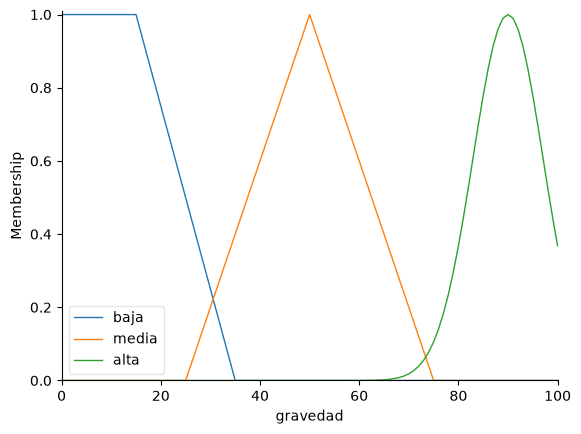

In [ ]:
# GRAVEDAD - valores difusos y funciones de pertenencia
# baja: hecho leve (trapezoidal)
gravedad['baja'] = fuzz.trapmf(gravedad.universe, [0, 0, 15, 35])

# media: hecho de gravedad intermedia (triangular)
gravedad['media'] = fuzz.trimf(gravedad.universe, [25, 50, 75])

# alta: hecho grave, ej. agresión física (Gaussiana)
gravedad['alta'] = fuzz.gaussmf(gravedad.universe, 90, 10)


gravedad.view()

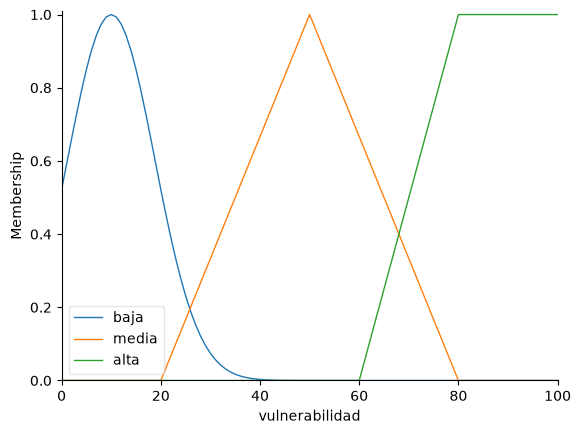

In [ ]:
# Vulnerabilidad

# baja: sin factores de vulnerabilidad 
vulnerabilidad['baja'] = fuzz.gaussmf(vulnerabilidad.universe, 10, 10)

# media: algunos factores de vulnerabilidad 
vulnerabilidad['media'] = fuzz.trimf(vulnerabilidad.universe, [20, 50, 80])

# alta: niño, adulto mayor o persona con discapacidad
vulnerabilidad['alta'] = fuzz.trapmf(vulnerabilidad.universe, [60, 80, 100, 100])

vulnerabilidad.view()

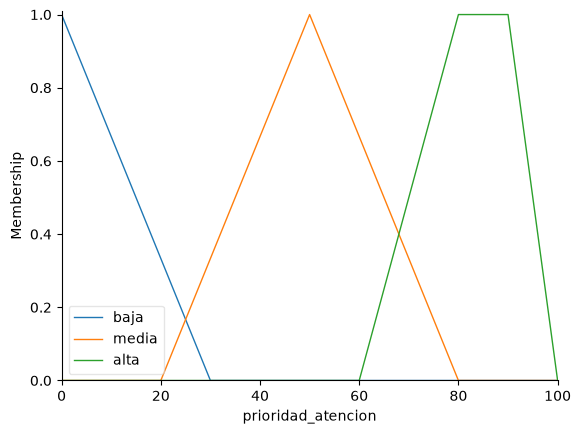

In [31]:
# Prioridad de atención

# baja: casos que pueden esperar 
prioridad_atencion['baja'] = fuzz.trimf(prioridad_atencion.universe, [0, 0, 30])

# media: prioridad intermedia
prioridad_atencion['media'] = fuzz.trimf(prioridad_atencion.universe, [20, 50, 80])

# alta: requiere atención pronta 
prioridad_atencion['alta'] = fuzz.trapmf(prioridad_atencion.universe, [60, 80, 90, 100])

prioridad_atencion.view()

## Módulo de Ontología: